# ♻️ ITGAM WasteAI — Fase 1: Entrenamiento EfficientNet-B0

**Desarrollador:** José Armando Cid González  
**Institución:** Instituto Tecnológico de Gustavo A. Madero (ITGAM) — TecNM  
**Normativa:** ITGAM-GA-007 (SGA bajo ISO 14001:2015)

### Clases del modelo (alineadas a ITGAM-GA-007)
| ID | Clase | Descripción |
|---|---|---|
| 0 | `organico` | Restos de comida, cáscaras, residuos vegetales |
| 1 | `inorganico_reciclable` | Botellas PET, latas, papel limpio, cartón |
| 2 | `no_aprovechable` | Servilletas sucias, envolturas metalizadas, papel de baño |
| 3 | `peligroso` | Residuos de laboratorio, químicos, aceites |

### Pasos del notebook
1. Instalar dependencias
2. Descargar TrashNet + TACO ligero
3. Mapear clases originales → clases ITGAM
4. Preprocesamiento y data augmentation
5. Entrenamiento de EfficientNet-B0 (PyTorch)
6. Evaluación del modelo
7. Exportación a TensorFlow.js

> ⚡ **Runtime recomendado:** GPU T4 (Entorno de ejecución → Cambiar tipo de entorno de ejecución → T4 GPU)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

---
## Celda 1 — Instalar dependencias

In [ ]:
# ============================================================
# CELDA 1: Instalación de dependencias
# onnx + onnx2tf permiten el puente PyTorch → TensorFlow.js
# ============================================================

!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q efficientnet_pytorch
!pip install -q onnx onnx2tf tensorflow
!pip install -q kaggle
!pip install -q tensorflowjs
!pip install -q Pillow matplotlib seaborn scikit-learn tqdm

print('✅ Dependencias instaladas correctamente.')

---
## Celda 2 — Configuración global

In [ ]:
# ============================================================
# CELDA 2: Configuración global del proyecto
# Todos los hiperparámetros y rutas en un solo lugar.
# ============================================================

import os
import torch

# --- Rutas del proyecto ---
RUTA_BASE        = '/content/itgam_wasteai'
RUTA_DATASET     = os.path.join(RUTA_BASE, 'dataset_unificado')
RUTA_TRASHNET    = os.path.join(RUTA_BASE, 'trashnet')
RUTA_TACO        = os.path.join(RUTA_BASE, 'taco')
RUTA_MODELO_PT   = os.path.join(RUTA_BASE, 'modelo_pytorch')
RUTA_MODELO_ONNX = os.path.join(RUTA_BASE, 'modelo_onnx')
RUTA_MODELO_TFJS = os.path.join(RUTA_BASE, 'modelo_tfjs')

# Crear directorios si no existen
for ruta in [RUTA_BASE, RUTA_DATASET, RUTA_TRASHNET, RUTA_TACO,
             RUTA_MODELO_PT, RUTA_MODELO_ONNX, RUTA_MODELO_TFJS]:
    os.makedirs(ruta, exist_ok=True)

# --- Clases ITGAM-GA-007 ---
CLASES_ITGAM = [
    'organico',
    'inorganico_reciclable',
    'no_aprovechable',
    'peligroso'
]
NUM_CLASES = len(CLASES_ITGAM)

# --- Hiperparámetros de entrenamiento ---
BATCH_SIZE    = 32      # Ajustar a 16 si hay error de memoria en la GPU
NUM_EPOCHS    = 25      # Aumentar a 40 si el accuracy sigue subiendo
LR_INICIAL    = 1e-3    # Learning rate para la cabeza del clasificador
LR_FINETUNE   = 1e-4    # Learning rate para fine-tuning del backbone
SEED          = 42
SPLIT_VAL     = 0.15    # 15% para validación
SPLIT_TEST    = 0.10    # 10% para prueba final

# Tamaño de entrada de EfficientNet-B0
IMG_SIZE = 224

# --- Dispositivo ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Dispositivo detectado: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
else:
    print('⚠️  No se detectó GPU. El entrenamiento será lento. Cambia el runtime a T4.')

print(f'\n📂 Clases ITGAM-GA-007: {CLASES_ITGAM}')
print('✅ Configuración lista.')

---
## Celda 3 — Descargar TrashNet

In [ ]:
# ============================================================
# CELDA 3: Descarga de TrashNet desde Kaggle
#
# REQUISITO: Sube tu kaggle.json al panel de archivos de Colab
# (ícono de carpeta → subir archivo) antes de ejecutar.
# Obtén el token en: https://www.kaggle.com/settings → API
# ============================================================

import shutil

# Configurar credenciales de Kaggle
os.makedirs('/root/.kaggle', exist_ok=True)
if os.path.exists('/content/kaggle.json'):
    shutil.copy('/content/kaggle.json', '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    print('✅ kaggle.json configurado correctamente.')
else:
    print('❌ ERROR: Sube tu kaggle.json a /content/ antes de continuar.')
    print('   Ve a: https://www.kaggle.com/settings → API → Create New Token')

# Descargar TrashNet
# Slug verificado: feyzazkefe/trashnet
# Estructura descargada: carpetas por clase (cardboard, glass, metal, paper, plastic, trash)
print('\n📥 Descargando TrashNet (~500 MB)...')
!kaggle datasets download -d feyzazkefe/trashnet -p {RUTA_TRASHNET} --unzip
print('✅ TrashNet descargado.')

# Mostrar estructura real descargada
print('\n📁 Estructura de TrashNet:')
for raiz, dirs, archivos in os.walk(RUTA_TRASHNET):
    # Solo mostrar carpetas que tengan imágenes directamente dentro
    imagenes = [f for f in archivos if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png'}]
    if imagenes:
        nombre_rel = os.path.relpath(raiz, RUTA_TRASHNET)
        print(f'   {nombre_rel}: {len(imagenes)} imágenes')

---
## Celda 4 — Descargar TACO (versión ligera)

In [ ]:
# ============================================================
# CELDA 4: Descarga de TACO versión ligera (~1 GB)
#
# Slug verificado: kneroma/tacotrashdataset
#
# FORMATO REAL: TACO viene en formato COCO.
# NO tiene carpetas por clase — tiene:
#   data/          → imágenes crudas numeradas (batch_1/, batch_2/...)
#   annotations.json → anotaciones en formato COCO con categorías
#
# El mapeo de categorías a clases ITGAM se hace en la Celda 5
# parseando el JSON de anotaciones.
# ============================================================

print('📥 Descargando TACO (~1 GB)...')
!kaggle datasets download -d kneroma/tacotrashdataset -p {RUTA_TACO} --unzip
print('✅ TACO descargado.')

# Explorar la estructura real del dataset para confirmar rutas
print('\n📁 Estructura de TACO (2 niveles):')
for raiz, dirs, archivos in os.walk(RUTA_TACO):
    nivel = raiz.replace(RUTA_TACO, '').count(os.sep)
    if nivel > 2:
        continue
    indent = '   ' * nivel
    nombre = os.path.basename(raiz) or 'taco/'
    n_arch = len(archivos)
    print(f'{indent}{nombre}/  ({n_arch} archivos)')

# Localizar el JSON de anotaciones COCO automáticamente
import glob
jsons_encontrados = glob.glob(os.path.join(RUTA_TACO, '**', '*.json'), recursive=True)
print(f'\n📄 JSONs de anotaciones encontrados:')
for j in jsons_encontrados:
    tam_kb = os.path.getsize(j) / 1024
    print(f'   {os.path.relpath(j, RUTA_TACO)}  ({tam_kb:.0f} KB)')

# Guardar la ruta del JSON principal en una variable para la Celda 5
# Se elige el JSON más grande (el que contiene todas las anotaciones)
if jsons_encontrados:
    RUTA_TACO_JSON = max(jsons_encontrados, key=os.path.getsize)
    print(f'\n✅ JSON de anotaciones seleccionado: {os.path.relpath(RUTA_TACO_JSON, RUTA_TACO)}')
else:
    print('\n❌ ERROR: No se encontró ningún JSON. Verifica la descarga.')
    RUTA_TACO_JSON = None

---
## Celda 5 — Mapeo de clases a ITGAM-GA-007

In [ ]:
# ============================================================
# CELDA 5: Mapeo de clases originales → clases ITGAM-GA-007
#
# --- TrashNet ---
# 6 clases en carpetas: cardboard, glass, metal, paper, plastic, trash
# Mapeo directo por nombre de carpeta.
#
# --- TACO (formato COCO) ---
# Las categorías están en annotations.json, NO en carpetas.
# Estructura COCO relevante:
#   {
#     "categories": [{"id": 1, "name": "Aluminium foil", "supercategory": "..."}, ...],
#     "images":     [{"id": 1, "file_name": "batch_1/000001.jpg", ...}, ...],
#     "annotations":[{"id": 1, "image_id": 1, "category_id": 3, ...}, ...]
#   }
# Cada imagen puede tener varias anotaciones (objetos).
# Estrategia: asignar a la imagen la clase ITGAM de mayor riesgo
# entre todos sus objetos anotados (peligroso > no_aprovechable
# > inorganico_reciclable > organico).
# ============================================================

import json
import re
from collections import defaultdict

# ---- Mapa TrashNet ----
MAPA_TRASHNET = {
    'cardboard' : 'inorganico_reciclable',
    'glass'     : 'inorganico_reciclable',
    'metal'     : 'inorganico_reciclable',
    'paper'     : 'inorganico_reciclable',
    'plastic'   : 'inorganico_reciclable',
    'trash'     : 'no_aprovechable',
}

# ---- Mapa TACO: categoría COCO → clase ITGAM ----
# Basado en las 60 categorías reales del dataset TACO.
# Referencia: https://tacodataset.org/
# Se usa regex sobre el nombre de categoría en minúsculas.
MAPA_TACO_REGEX = [
    # PELIGROSO — prioridad más alta
    (r'battery|chemical|paint|oil|syringe|needle|medical|lab|toxic|hazard',
     'peligroso'),
    # ORGÁNICO
    (r'food|organic|fruit|vegetable|coffee|tea|egg|bread|bone',
     'organico'),
    # INORGÁNICO RECICLABLE
    (r'bottle|can|tin|alumin|metal|glass|plastic|pet|carton|cardboard|'
     r'paper|magazine|newspaper|cup.*plastic|cup.*paper|bag.*plastic|'
     r'container|jar|lid|cap|straw.*paper|six.pack|tetra',
     'inorganico_reciclable'),
    # NO APROVECHABLE — residuo por defecto
    (r'styrofoam|cigarette|straw|wrapper|sachet|tissue|napkin|foam|'
     r'diaper|mask|glove|tape|rubber|unlabeled|other|misc',
     'no_aprovechable'),
]

# Jerarquía de riesgo para resolver conflictos cuando una imagen
# tiene objetos de múltiples clases
JERARQUIA = {
    'peligroso'            : 3,
    'no_aprovechable'      : 2,
    'inorganico_reciclable': 1,
    'organico'             : 0,
}
CLASE_DEFAULT_TACO = 'no_aprovechable'

def mapear_categoria_taco(nombre_cat: str) -> str:
    """Mapea un nombre de categoría TACO a una clase ITGAM-GA-007."""
    nombre_lower = nombre_cat.lower()
    for patron, clase in MAPA_TACO_REGEX:
        if re.search(patron, nombre_lower):
            return clase
    return CLASE_DEFAULT_TACO


def parsear_coco_taco(ruta_json: str) -> dict:
    """
    Parsea el JSON de anotaciones COCO de TACO.
    Devuelve: { 'ruta_relativa_imagen': 'clase_itgam', ... }
    La clase asignada es la de mayor jerarquía entre todos
    los objetos anotados en esa imagen.
    """
    with open(ruta_json, 'r', encoding='utf-8') as f:
        datos = json.load(f)

    # 1. Construir mapa: category_id → clase_itgam
    id_a_clase = {}
    for cat in datos.get('categories', []):
        id_a_clase[cat['id']] = mapear_categoria_taco(cat['name'])

    # 2. Construir mapa: image_id → file_name
    id_a_imagen = {img['id']: img['file_name'] for img in datos.get('images', [])}

    # 3. Para cada imagen, acumular clases de sus anotaciones
    imagen_a_clases = defaultdict(set)
    for ann in datos.get('annotations', []):
        img_id  = ann['image_id']
        cat_id  = ann['category_id']
        clase   = id_a_clase.get(cat_id, CLASE_DEFAULT_TACO)
        imagen_a_clases[img_id].add(clase)

    # 4. Asignar clase final por jerarquía de riesgo
    resultado = {}
    for img_id, clases in imagen_a_clases.items():
        clase_final = max(clases, key=lambda c: JERARQUIA.get(c, 0))
        file_name   = id_a_imagen.get(img_id)
        if file_name:
            resultado[file_name] = clase_final

    return resultado


# Ejecutar el parser
if RUTA_TACO_JSON:
    TACO_IMAGEN_A_CLASE = parsear_coco_taco(RUTA_TACO_JSON)

    # Reporte de distribución
    conteo_taco = defaultdict(int)
    for clase in TACO_IMAGEN_A_CLASE.values():
        conteo_taco[clase] += 1

    print(f'📊 TACO: {len(TACO_IMAGEN_A_CLASE)} imágenes parseadas del JSON COCO')
    print(f'\nDistribución TACO → clases ITGAM-GA-007:')
    print(f'{"Clase ITGAM":<25} {"Imágenes"}')
    print('-' * 35)
    for clase in CLASES_ITGAM:
        n = conteo_taco.get(clase, 0)
        print(f'{clase:<25} {n:>6}')

    # Vista previa del mapeo de categorías
    print('\n📋 Muestra de mapeo de categorías TACO → ITGAM:')
    with open(RUTA_TACO_JSON, 'r') as f:
        datos_preview = json.load(f)
    print(f'{"Categoría TACO":<35} {"Clase ITGAM"}')
    print('-' * 55)
    for cat in sorted(datos_preview.get('categories', []), key=lambda x: x['name']):
        clase = mapear_categoria_taco(cat['name'])
        print(f"{cat['name']:<35} → {clase}")
else:
    print('⚠️  Saltando parseo TACO: no se encontró JSON de anotaciones.')
    TACO_IMAGEN_A_CLASE = {}

print('\n✅ Mapeos definidos.')

---
## Celda 6 — Construir dataset unificado

In [ ]:
# ============================================================
# CELDA 6: Copiar imágenes al dataset unificado
# Estructura final:
#   /dataset_unificado/
#       organico/
#       inorganico_reciclable/
#       no_aprovechable/
#       peligroso/
# ============================================================

import shutil
from pathlib import Path
from tqdm import tqdm

EXTENSIONES_VALIDAS = {'.jpg', '.jpeg', '.png', '.webp'}

# Crear subcarpetas por clase
for clase in CLASES_ITGAM:
    os.makedirs(os.path.join(RUTA_DATASET, clase), exist_ok=True)

conteo = {c: 0 for c in CLASES_ITGAM}

def copiar_imagen(src: str, clase_itgam: str, prefijo: str):
    """Copia una imagen al directorio de la clase correspondiente."""
    ext = Path(src).suffix.lower()
    if ext not in EXTENSIONES_VALIDAS:
        return
    destino_dir = os.path.join(RUTA_DATASET, clase_itgam)
    # Nombre único para evitar colisiones entre datasets
    nombre = f'{prefijo}_{conteo[clase_itgam]:05d}{ext}'
    destino = os.path.join(destino_dir, nombre)
    shutil.copy2(src, destino)
    conteo[clase_itgam] += 1

# --- Procesar TrashNet ---
print('📦 Procesando TrashNet...')
for carpeta in os.listdir(RUTA_TRASHNET):
    clase_itgam = MAPA_TRASHNET.get(carpeta.lower())
    if clase_itgam is None:
        print(f'  ⚠️  Carpeta no mapeada en TrashNet: {carpeta}')
        continue
    ruta_carpeta = os.path.join(RUTA_TRASHNET, carpeta)
    if not os.path.isdir(ruta_carpeta):
        continue
    archivos = os.listdir(ruta_carpeta)
    for archivo in tqdm(archivos, desc=f'  {carpeta} → {clase_itgam}', leave=False):
        copiar_imagen(os.path.join(ruta_carpeta, archivo), clase_itgam, f'tn_{carpeta}')

# --- Procesar TACO (formato COCO) ---
# TACO_IMAGEN_A_CLASE = { 'batch_1/000001.jpg': 'inorganico_reciclable', ... }
# Las rutas son relativas a la raíz de RUTA_TACO.
print('\n📦 Procesando TACO (formato COCO)...')
taco_no_encontradas = 0
for file_name, clase_itgam in tqdm(TACO_IMAGEN_A_CLASE.items(),
                                    desc='  TACO → dataset unificado', leave=False):
    ruta_img = os.path.join(RUTA_TACO, file_name)
    if not os.path.exists(ruta_img):
        # Algunos file_name pueden tener prefijo 'data/' u otra variante
        ruta_alt = os.path.join(RUTA_TACO, 'data', file_name)
        if os.path.exists(ruta_alt):
            ruta_img = ruta_alt
        else:
            taco_no_encontradas += 1
            continue
    # Usar los primeros 6 chars del filename como prefijo para unicidad
    prefijo = 'taco_' + file_name.replace('/', '_').replace('.', '_')[:12]
    copiar_imagen(ruta_img, clase_itgam, prefijo)

if taco_no_encontradas > 0:
    print(f'  ⚠️  {taco_no_encontradas} imágenes del JSON no encontradas en disco (normal si el dataset es parcial)')

# --- Reporte final ---
print('\n📊 Distribución del dataset unificado:')
print(f'{"Clase":<25} {"Imágenes"}')
print('-' * 35)
total = 0
for clase, n in conteo.items():
    print(f'{clase:<25} {n:>6}')
    total += n
print('-' * 35)
print(f'{"TOTAL":<25} {total:>6}')
print('\n✅ Dataset unificado construido.')

---
## Celda 7 — Visualizar muestras del dataset

In [ ]:
# ============================================================
# CELDA 7: Visualización de muestras por clase
# Útil para verificar que el mapeo fue correcto.
# ============================================================

import matplotlib.pyplot as plt
import random
from PIL import Image

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('Muestras del dataset ITGAM WasteAI', fontsize=16, fontweight='bold')

for fila, clase in enumerate(CLASES_ITGAM):
    ruta_clase = os.path.join(RUTA_DATASET, clase)
    archivos = [f for f in os.listdir(ruta_clase)
                if Path(f).suffix.lower() in EXTENSIONES_VALIDAS]
    muestras = random.sample(archivos, min(5, len(archivos)))

    for col, archivo in enumerate(muestras):
        img = Image.open(os.path.join(ruta_clase, archivo)).convert('RGB')
        axes[fila][col].imshow(img)
        axes[fila][col].axis('off')
        if col == 0:
            axes[fila][col].set_title(clase, fontsize=10, fontweight='bold', loc='left')

plt.tight_layout()
plt.savefig(os.path.join(RUTA_BASE, 'muestras_dataset.png'), dpi=150)
plt.show()
print('✅ Visualización guardada en muestras_dataset.png')

---
## Celda 8 — Preprocesamiento y data augmentation

In [ ]:
# ============================================================
# CELDA 8: Preprocesamiento y data augmentation
#
# Train: augmentation agresivo para generalizar
# Val/Test: solo resize + normalización (sin augmentation)
#
# Normalización: media y std de ImageNet (estándar para
# transfer learning con EfficientNet pre-entrenado).
# ============================================================

import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Media y desviación estándar de ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# --- Transformaciones para entrenamiento ---
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),  # Un poco más grande para el crop
    transforms.RandomCrop(IMG_SIZE),                     # Recorte aleatorio
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.05
    ),
    # Simula condiciones de luz variables del campus
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# --- Transformaciones para validación y prueba ---
transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# --- Cargar el dataset completo con ImageFolder ---
# ImageFolder espera la estructura: raiz/clase/imagen.jpg
dataset_completo = datasets.ImageFolder(root=RUTA_DATASET)

# Verificar que las clases coinciden con ITGAM
print(f'Clases detectadas por ImageFolder: {dataset_completo.classes}')
print(f'Clases esperadas (ITGAM-GA-007):   {sorted(CLASES_ITGAM)}')
assert sorted(dataset_completo.classes) == sorted(CLASES_ITGAM), \
    '❌ ERROR: Las clases no coinciden. Revisa la estructura de carpetas.'

# --- División estratificada del dataset ---
torch.manual_seed(SEED)
n_total = len(dataset_completo)
n_test  = int(n_total * SPLIT_TEST)
n_val   = int(n_total * SPLIT_VAL)
n_train = n_total - n_val - n_test

dataset_train_raw, dataset_val_raw, dataset_test_raw = random_split(
    dataset_completo, [n_train, n_val, n_test]
)

# Aplicar transformaciones a cada split
# Usando Subset + transform override
class SubsetConTransform(torch.utils.data.Dataset):
    """Wrapper que aplica una transformación diferente a un Subset."""
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        imagen, etiqueta = self.subset[idx]
        if self.transform:
            # subset[idx] devuelve PIL Image cuando el dataset base
            # no tiene transform asignado
            imagen = self.transform(imagen)
        return imagen, etiqueta

# Quitar transform del dataset base para que SubsetConTransform lo controle
dataset_completo.transform = None

dataset_train = SubsetConTransform(dataset_train_raw, transform_train)
dataset_val   = SubsetConTransform(dataset_val_raw,   transform_val)
dataset_test  = SubsetConTransform(dataset_test_raw,  transform_val)

# --- DataLoaders ---
loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
loader_val   = DataLoader(dataset_val,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
loader_test  = DataLoader(dataset_test,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'\n📊 División del dataset:')
print(f'   Train : {n_train:>5} imágenes ({n_train/n_total*100:.1f}%)')
print(f'   Val   : {n_val:>5} imágenes ({n_val/n_total*100:.1f}%)')
print(f'   Test  : {n_test:>5} imágenes ({n_test/n_total*100:.1f}%)')
print(f'   Total : {n_total:>5} imágenes')
print('\n✅ DataLoaders listos.')

---
## Celda 9 — Construir modelo EfficientNet-B0

In [ ]:
# ============================================================
# CELDA 9: Construcción del modelo EfficientNet-B0
#
# Estrategia de transfer learning en dos etapas:
#   Etapa 1 (Fase caliente): Solo se entrena la cabeza
#             clasificadora. El backbone se congela.
#   Etapa 2 (Fine-tuning): Se descongela todo el modelo
#             con un learning rate menor para ajuste fino.
# ============================================================

import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

def construir_modelo(num_clases: int, congelar_backbone: bool = True):
    """
    Construye EfficientNet-B0 pre-entrenado en ImageNet
    con cabeza clasificadora para `num_clases` clases.
    """
    # Cargar pesos pre-entrenados en ImageNet
    modelo = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

    if congelar_backbone:
        # Congelar todos los parámetros del backbone
        for parametro in modelo.features.parameters():
            parametro.requires_grad = False

    # Reemplazar la cabeza clasificadora por defecto (1000 clases)
    # por una nueva de `num_clases` clases
    in_features = modelo.classifier[1].in_features  # 1280 en B0
    modelo.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_clases)
    )

    return modelo

# Construir modelo con backbone congelado (Etapa 1)
modelo = construir_modelo(NUM_CLASES, congelar_backbone=True)
modelo = modelo.to(DEVICE)

# Resumen de parámetros
total_params     = sum(p.numel() for p in modelo.parameters())
trainable_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f'📐 EfficientNet-B0 cargado:')
print(f'   Parámetros totales    : {total_params:>10,}')
print(f'   Parámetros entrenables: {trainable_params:>10,}  ({trainable_params/total_params*100:.1f}%)')
print(f'   Clases de salida      : {NUM_CLASES} → {CLASES_ITGAM}')
print('\n✅ Modelo listo en', DEVICE)

---
## Celda 10 — Funciones de entrenamiento y evaluación

In [ ]:
# ============================================================
# CELDA 10: Funciones de entrenamiento y evaluación
# ============================================================

import time
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def entrenar_epoch(modelo, loader, optimizer, criterion, device):
    """Ejecuta una época de entrenamiento. Devuelve (loss, accuracy)."""
    modelo.train()
    loss_total = 0.0
    correctos  = 0
    total      = 0

    for imagenes, etiquetas in loader:
        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)

        optimizer.zero_grad()
        salidas = modelo(imagenes)
        loss    = criterion(salidas, etiquetas)
        loss.backward()
        optimizer.step()

        loss_total += loss.item() * imagenes.size(0)
        _, predicciones = salidas.max(1)
        correctos += predicciones.eq(etiquetas).sum().item()
        total     += imagenes.size(0)

    return loss_total / total, correctos / total


def evaluar(modelo, loader, criterion, device):
    """Evalúa el modelo en un loader. Devuelve (loss, accuracy)."""
    modelo.eval()
    loss_total = 0.0
    correctos  = 0
    total      = 0

    with torch.no_grad():
        for imagenes, etiquetas in loader:
            imagenes  = imagenes.to(device)
            etiquetas = etiquetas.to(device)

            salidas = modelo(imagenes)
            loss    = criterion(salidas, etiquetas)

            loss_total += loss.item() * imagenes.size(0)
            _, predicciones = salidas.max(1)
            correctos += predicciones.eq(etiquetas).sum().item()
            total     += imagenes.size(0)

    return loss_total / total, correctos / total


def ciclo_entrenamiento(modelo, loader_train, loader_val, optimizer,
                        criterion, scheduler, num_epochs, device,
                        ruta_mejor_modelo, etiqueta='Etapa',
                        ruta_drive_checkpoints=None):
    """
    Ciclo completo de entrenamiento con:
    - Guardado del mejor modelo por val_accuracy
    - Early stopping (paciencia = 7 epochs sin mejora)
    - Checkpoint periódico cada 5 épocas a Google Drive
      (protege contra desconexiones de Colab)
    - Historial de métricas

    Args:
        ruta_drive_checkpoints: carpeta en Drive donde guardar checkpoints
                                periódicos. Si es None, se omite.
    """
    mejor_val_acc = 0.0
    epochs_sin_mejora = 0
    PACIENCIA = 7
    FRECUENCIA_CHECKPOINT = 5  # Guardar a Drive cada N épocas

    historial = {'train_loss': [], 'train_acc': [],
                 'val_loss':   [], 'val_acc':   []}

    # Crear carpeta de checkpoints en Drive si se especificó
    if ruta_drive_checkpoints:
        os.makedirs(ruta_drive_checkpoints, exist_ok=True)

    print(f'\n{"="*60}')
    print(f'  {etiqueta}: {num_epochs} épocas máx | Early stop: {PACIENCIA} épocas')
    if ruta_drive_checkpoints:
        print(f'  💾 Checkpoint a Drive cada {FRECUENCIA_CHECKPOINT} épocas')
    print(f'{"="*60}')

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()

        train_loss, train_acc = entrenar_epoch(modelo, loader_train, optimizer, criterion, device)
        val_loss,   val_acc   = evaluar(modelo, loader_val, criterion, device)

        if scheduler:
            scheduler.step(val_loss)

        historial['train_loss'].append(train_loss)
        historial['train_acc'].append(train_acc)
        historial['val_loss'].append(val_loss)
        historial['val_acc'].append(val_acc)

        t1 = time.time()
        mejora = '⭐' if val_acc > mejor_val_acc else '  '
        print(f'  Epoch {epoch:>3}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.3f} | '
              f'{t1-t0:.1f}s {mejora}')

        # --- Guardar mejor modelo (local) ---
        if val_acc > mejor_val_acc:
            mejor_val_acc = val_acc
            epochs_sin_mejora = 0
            torch.save({
                'epoch':           epoch,
                'model_state':     modelo.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'val_acc':         val_acc,
                'clases':          CLASES_ITGAM,
            }, ruta_mejor_modelo)
        else:
            epochs_sin_mejora += 1
            if epochs_sin_mejora >= PACIENCIA:
                print(f'\n  🛑 Early stopping: {PACIENCIA} épocas sin mejora.')
                # Checkpoint de emergencia antes de salir
                if ruta_drive_checkpoints:
                    _guardar_checkpoint_drive(
                        modelo, optimizer, epoch, val_acc, historial,
                        ruta_drive_checkpoints, etiqueta, sufijo='early_stop'
                    )
                break

        # --- Checkpoint periódico a Google Drive ---
        if ruta_drive_checkpoints and epoch % FRECUENCIA_CHECKPOINT == 0:
            _guardar_checkpoint_drive(
                modelo, optimizer, epoch, val_acc, historial,
                ruta_drive_checkpoints, etiqueta
            )

    # Checkpoint final al terminar todas las épocas
    if ruta_drive_checkpoints:
        _guardar_checkpoint_drive(
            modelo, optimizer, epoch, val_acc, historial,
            ruta_drive_checkpoints, etiqueta, sufijo='final'
        )
        # También copiar el mejor modelo a Drive
        nombre_mejor = os.path.basename(ruta_mejor_modelo)
        shutil.copy2(ruta_mejor_modelo,
                     os.path.join(ruta_drive_checkpoints, f'MEJOR_{nombre_mejor}'))
        print(f'  ☁️  Mejor modelo copiado a Drive.')

    print(f'\n  ✅ {etiqueta} finalizado. Mejor val_acc: {mejor_val_acc:.4f}')
    return historial


def _guardar_checkpoint_drive(modelo, optimizer, epoch, val_acc, historial,
                               ruta_drive, etiqueta, sufijo=None):
    """
    Guarda un checkpoint completo en Google Drive.
    Incluye estado del modelo, optimizer, historial y métricas.
    Nombrado con época para no sobreescribir checkpoints previos.
    """
    etiqueta_safe = etiqueta.replace(' ', '_').replace('—', '').lower()
    sufijo_str    = f'_{sufijo}' if sufijo else ''
    nombre        = f'ckpt_{etiqueta_safe}_ep{epoch:03d}{sufijo_str}.pth'
    ruta_destino  = os.path.join(ruta_drive, nombre)

    torch.save({
        'epoch'          : epoch,
        'model_state'    : modelo.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'val_acc'        : val_acc,
        'historial'      : historial,
        'clases'         : CLASES_ITGAM,
    }, ruta_destino)
    print(f'  💾 Checkpoint guardado en Drive: {nombre}')

def graficar_historial(historial, titulo='Entrenamiento'):
    """Grafica curvas de loss y accuracy del entrenamiento."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(titulo, fontsize=14, fontweight='bold')

    epochs = range(1, len(historial['train_loss']) + 1)

    ax1.plot(epochs, historial['train_loss'], label='Train', marker='o', markersize=3)
    ax1.plot(epochs, historial['val_loss'],   label='Val',   marker='o', markersize=3)
    ax1.set_title('Loss')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, [a*100 for a in historial['train_acc']], label='Train', marker='o', markersize=3)
    ax2.plot(epochs, [a*100 for a in historial['val_acc']],   label='Val',   marker='o', markersize=3)
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    nombre_archivo = titulo.replace(' ', '_').lower() + '.png'
    plt.savefig(os.path.join(RUTA_BASE, nombre_archivo), dpi=150)
    plt.show()

print('✅ Funciones de entrenamiento definidas.')

---
## Celda 11 — Etapa 1: Entrenar solo la cabeza clasificadora

In [ ]:
# ============================================================
# CELDA 11: Etapa 1 — Calentar la cabeza clasificadora
#
# El backbone (EfficientNet features) está congelado.
# Solo se entrenan los parámetros de la nueva cabeza.
# Esto evita destruir los pesos pre-entrenados al inicio.
#
# Se monta Google Drive ANTES de entrenar para que el
# checkpoint periódico funcione aunque Colab se desconecte.
# ============================================================

import torch.optim as optim
import shutil
from google.colab import drive

# Montar Google Drive (si aún no está montado)
if not os.path.exists('/content/drive/MyDrive'):
    print('📁 Montando Google Drive...')
    drive.mount('/content/drive')
else:
    print('✅ Google Drive ya montado.')

RUTA_DRIVE             = '/content/drive/MyDrive/ITGAM_WasteAI'
RUTA_DRIVE_CKPT_E1     = os.path.join(RUTA_DRIVE, 'checkpoints_etapa1')
os.makedirs(RUTA_DRIVE_CKPT_E1, exist_ok=True)
print(f'💾 Carpeta de checkpoints Etapa 1: {RUTA_DRIVE_CKPT_E1}')

# Solo optimizar parámetros entrenables (la cabeza)
optimizer_etapa1 = optim.Adam(
    filter(lambda p: p.requires_grad, modelo.parameters()),
    lr=LR_INICIAL
)

# ReduceLROnPlateau: reduce LR cuando val_loss deja de bajar
scheduler_etapa1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_etapa1, mode='min', factor=0.5, patience=3, verbose=True
)

# Función de pérdida: Cross-Entropy estándar para clasificación
criterion = nn.CrossEntropyLoss()

RUTA_MEJOR_MODELO_E1 = os.path.join(RUTA_MODELO_PT, 'mejor_etapa1.pth')

historial_e1 = ciclo_entrenamiento(
    modelo                  = modelo,
    loader_train            = loader_train,
    loader_val              = loader_val,
    optimizer               = optimizer_etapa1,
    criterion               = criterion,
    scheduler               = scheduler_etapa1,
    num_epochs              = 10,
    device                  = DEVICE,
    ruta_mejor_modelo       = RUTA_MEJOR_MODELO_E1,
    etiqueta                = 'Etapa 1 — Cabeza clasificadora',
    ruta_drive_checkpoints  = RUTA_DRIVE_CKPT_E1,  # ← checkpoint cada 5 épocas
)

graficar_historial(historial_e1, titulo='Etapa 1 — Cabeza clasificadora')

---
## Celda 12 — Etapa 2: Fine-tuning del modelo completo

In [ ]:
# ============================================================
# CELDA 12: Etapa 2 — Fine-tuning completo
#
# Cargar el mejor modelo de la Etapa 1, descongelar el
# backbone y entrenar con un LR muy pequeño.
#
# Google Drive ya está montado desde la Celda 11.
# Los checkpoints se guardan cada 5 épocas en:
#   MyDrive/ITGAM_WasteAI/checkpoints_etapa2/
# ============================================================

RUTA_DRIVE_CKPT_E2 = os.path.join(RUTA_DRIVE, 'checkpoints_etapa2')
os.makedirs(RUTA_DRIVE_CKPT_E2, exist_ok=True)
print(f'💾 Carpeta de checkpoints Etapa 2: {RUTA_DRIVE_CKPT_E2}')

# Cargar el mejor checkpoint de la Etapa 1
checkpoint = torch.load(RUTA_MEJOR_MODELO_E1, map_location=DEVICE)
modelo.load_state_dict(checkpoint['model_state'])
print(f'✅ Cargado mejor modelo de Etapa 1 (val_acc={checkpoint["val_acc"]:.4f})')

# Descongelar TODOS los parámetros del backbone
for parametro in modelo.features.parameters():
    parametro.requires_grad = True

total_params     = sum(p.numel() for p in modelo.parameters())
trainable_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f'   Parámetros entrenables ahora: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)')

# Optimizador con grupos de LR diferenciados
# El backbone usa LR 10x menor que la cabeza
optimizer_etapa2 = optim.AdamW([
    {'params': modelo.features.parameters(),    'lr': LR_FINETUNE},
    {'params': modelo.classifier.parameters(),  'lr': LR_FINETUNE * 5}
], weight_decay=1e-4)

scheduler_etapa2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_etapa2, T_max=NUM_EPOCHS, eta_min=1e-6
)

RUTA_MEJOR_MODELO_E2 = os.path.join(RUTA_MODELO_PT, 'mejor_etapa2.pth')

historial_e2 = ciclo_entrenamiento(
    modelo                  = modelo,
    loader_train            = loader_train,
    loader_val              = loader_val,
    optimizer               = optimizer_etapa2,
    criterion               = criterion,
    scheduler               = scheduler_etapa2,
    num_epochs              = NUM_EPOCHS,
    device                  = DEVICE,
    ruta_mejor_modelo       = RUTA_MEJOR_MODELO_E2,
    etiqueta                = 'Etapa 2 — Fine-tuning completo',
    ruta_drive_checkpoints  = RUTA_DRIVE_CKPT_E2,  # ← checkpoint cada 5 épocas
)

graficar_historial(historial_e2, titulo='Etapa 2 — Fine-tuning completo')

---
## Celda 13 — Evaluación final en el set de prueba

In [ ]:
# ============================================================
# CELDA 13: Evaluación final en el set de prueba
#
# Se usa el mejor modelo de la Etapa 2 para la evaluación.
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Cargar mejor modelo final
checkpoint_final = torch.load(RUTA_MEJOR_MODELO_E2, map_location=DEVICE)
modelo.load_state_dict(checkpoint_final['model_state'])
print(f'✅ Cargado mejor modelo (val_acc={checkpoint_final["val_acc"]:.4f})')

# Inferencia sobre el set de prueba
modelo.eval()
todas_predicciones = []
todas_etiquetas    = []

with torch.no_grad():
    for imagenes, etiquetas in loader_test:
        imagenes  = imagenes.to(DEVICE)
        salidas   = modelo(imagenes)
        _, preds  = salidas.max(1)
        todas_predicciones.extend(preds.cpu().numpy())
        todas_etiquetas.extend(etiquetas.numpy())

# Obtener nombres de clase del dataset
nombres_clases = dataset_completo.classes

# Reporte de clasificación
print('\n📊 Reporte de Clasificación (set de prueba):')
print(classification_report(todas_etiquetas, todas_predicciones,
                             target_names=nombres_clases))

# Matriz de confusión
cm = confusion_matrix(todas_etiquetas, todas_predicciones)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases,
            yticklabels=nombres_clases)
plt.title('Matriz de Confusión — ITGAM WasteAI', fontweight='bold')
plt.ylabel('Clase real')
plt.xlabel('Clase predicha')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RUTA_BASE, 'matriz_confusion.png'), dpi=150)
plt.show()
print('✅ Matriz de confusión guardada.')

---
## Celda 14 — Exportar a ONNX

In [ ]:
# ============================================================
# CELDA 14: Exportar modelo PyTorch → ONNX
#
# ONNX es el formato intermedio que usaremos para llegar
# a TensorFlow.js. Cadena: PyTorch → ONNX → TF SavedModel → TFJS
# ============================================================

import torch

# Cargar mejor modelo
checkpoint_final = torch.load(RUTA_MEJOR_MODELO_E2, map_location=DEVICE)
modelo.load_state_dict(checkpoint_final['model_state'])
modelo.eval()

# Input dummy con las dimensiones correctas: (batch, canales, alto, ancho)
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

RUTA_ONNX = os.path.join(RUTA_MODELO_ONNX, 'wasteai_efficientnet_b0.onnx')

torch.onnx.export(
    modelo,
    dummy_input,
    RUTA_ONNX,
    opset_version   = 12,           # Compatible con onnx2tf
    input_names      = ['input'],
    output_names     = ['output'],
    dynamic_axes     = {            # Permite batch size variable en inferencia
        'input':  {0: 'batch_size'},
        'output': {0: 'batch_size'}
    },
    export_params    = True,
    do_constant_folding = True,
)

print(f'✅ Modelo exportado a ONNX: {RUTA_ONNX}')
print(f'   Tamaño: {os.path.getsize(RUTA_ONNX) / 1024 / 1024:.1f} MB')

# Verificar que el ONNX es válido
import onnx
modelo_onnx = onnx.load(RUTA_ONNX)
onnx.checker.check_model(modelo_onnx)
print('✅ Verificación ONNX: el modelo es válido.')

---
## Celda 15 — Convertir ONNX → TensorFlow SavedModel

In [ ]:
# ============================================================
# CELDA 15: ONNX → TensorFlow SavedModel
# onnx2tf hace la conversión automáticamente.
# ============================================================

RUTA_TF_SAVEDMODEL = os.path.join(RUTA_BASE, 'modelo_tf_savedmodel')

print('🔄 Convirtiendo ONNX → TensorFlow SavedModel...')
!onnx2tf \
    -i {RUTA_ONNX} \
    -o {RUTA_TF_SAVEDMODEL} \
    -osd \
    -b 1

print(f'\n✅ TF SavedModel guardado en: {RUTA_TF_SAVEDMODEL}')
!ls -lh {RUTA_TF_SAVEDMODEL}

---
## Celda 16 — Convertir TF SavedModel → TensorFlow.js

In [ ]:
# ============================================================
# CELDA 16: TF SavedModel → TensorFlow.js
#
# tensorflowjs_converter genera:
#   model.json         → arquitectura + metadatos
#   group1-shard*.bin  → pesos del modelo
#
# Estos archivos se subirán a Google Drive y luego a Vercel.
# ============================================================

print('🔄 Convirtiendo TF SavedModel → TensorFlow.js...')
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    --signature_name=serving_default \
    --saved_model_tags=serve \
    {RUTA_TF_SAVEDMODEL} \
    {RUTA_MODELO_TFJS}

print(f'\n✅ Modelo TensorFlow.js generado en: {RUTA_MODELO_TFJS}')
print('\n📁 Archivos generados:')
for archivo in sorted(os.listdir(RUTA_MODELO_TFJS)):
    ruta = os.path.join(RUTA_MODELO_TFJS, archivo)
    tam  = os.path.getsize(ruta) / 1024
    print(f'   {archivo:<40} {tam:.1f} KB')

tam_total = sum(
    os.path.getsize(os.path.join(RUTA_MODELO_TFJS, f))
    for f in os.listdir(RUTA_MODELO_TFJS)
) / 1024 / 1024
print(f'\n   Tamaño total del modelo TFJS: {tam_total:.1f} MB')

---
## Celda 17 — Guardar metadatos del modelo (clases + normalización)

In [ ]:
# ============================================================
# CELDA 17: Guardar metadatos del modelo
#
# El frontend en TF.js necesita saber:
#   - Las clases en el orden correcto (índice → nombre)
#   - Los valores de normalización (media y std de ImageNet)
#
# Este JSON se sube junto con los archivos del modelo a Vercel.
# ============================================================

import json

# Orden exacto de clases según el índice del modelo
# (ImageFolder ordena las carpetas alfabéticamente)
clases_ordenadas = dataset_completo.classes

metadatos = {
    "nombre_modelo": "ITGAM WasteAI EfficientNet-B0",
    "version": "1.0.0",
    "normativa": "ITGAM-GA-007 / ISO 14001:2015",
    "institucion": "Instituto Tecnológico de Gustavo A. Madero — TecNM",
    "input_size": IMG_SIZE,
    "num_clases": NUM_CLASES,
    "clases": clases_ordenadas,
    "normalizacion": {
        "mean": IMAGENET_MEAN,
        "std":  IMAGENET_STD
    },
    "mapeo_contenedor_itgam": {
        "organico":              {"color": "por_confirmar", "etiqueta": "ORGÁNICO"},
        "inorganico_reciclable": {"color": "por_confirmar", "etiqueta": "INORGÁNICO RECICLABLE"},
        "no_aprovechable":       {"color": "por_confirmar", "etiqueta": "NO APROVECHABLE"},
        "peligroso":             {"color": "rojo",          "etiqueta": "RESIDUO PELIGROSO"}
    }
}

RUTA_METADATOS = os.path.join(RUTA_MODELO_TFJS, 'metadata.json')
with open(RUTA_METADATOS, 'w', encoding='utf-8') as f:
    json.dump(metadatos, f, ensure_ascii=False, indent=2)

print(f'✅ Metadatos guardados en: {RUTA_METADATOS}')
print(f'\nContenido:')
print(json.dumps(metadatos, ensure_ascii=False, indent=2))

---
## Celda 18 — Comprimir y subir a Google Drive

In [ ]:
# ============================================================
# CELDA 18: Comprimir modelo TFJS y subir a Google Drive
#
# El ZIP contendrá todos los archivos necesarios para Vercel:
#   model.json, group1-shard*.bin, metadata.json
# ============================================================

from google.colab import drive

# Montar Google Drive
print('📁 Montando Google Drive...')
drive.mount('/content/drive')

# Crear carpeta de destino en Drive
RUTA_DRIVE = '/content/drive/MyDrive/ITGAM_WasteAI'
os.makedirs(RUTA_DRIVE, exist_ok=True)

# Comprimir el modelo TFJS
RUTA_ZIP = os.path.join(RUTA_BASE, 'modelo_tfjs.zip')
print('\n📦 Comprimiendo modelo TFJS...')
!cd {RUTA_BASE} && zip -r modelo_tfjs.zip modelo_tfjs/

# Copiar a Drive
print('\n☁️  Copiando a Google Drive...')
shutil.copy2(RUTA_ZIP, os.path.join(RUTA_DRIVE, 'modelo_tfjs.zip'))

# También copiar el checkpoint PyTorch por si se necesita re-entrenar
shutil.copy2(RUTA_MEJOR_MODELO_E2, os.path.join(RUTA_DRIVE, 'mejor_modelo_pytorch.pth'))

# Copiar gráficas
for archivo in ['muestras_dataset.png', 'matriz_confusion.png',
                'etapa_1_—_cabeza_clasificadora.png', 'etapa_2_—_fine-tuning_completo.png']:
    src = os.path.join(RUTA_BASE, archivo)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(RUTA_DRIVE, archivo))

print(f'\n✅ Archivos guardados en Google Drive: {RUTA_DRIVE}')
print('\n📁 Contenido en Drive:')
!ls -lh {RUTA_DRIVE}

In [ ]:
# ============================================================
# CELDA 1 — Instalar datasets y descargar
# ============================================================
!pip install -q kaggle
import os

os.makedirs('/content/datasets_v2', exist_ok=True)

# Dataset 1: alistairking
!pip install -q opendatasets
import opendatasets as od
od.download('https://www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification',
            '/content/datasets_v2')

# Dataset 2: sumn2u
od.download('https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2',
            '/content/datasets_v2')

# Dataset 3: e-waste
od.download('https://www.kaggle.com/datasets/akshaybhola/e-waste-image-dataset',
            '/content/datasets_v2')

print('✅ Datasets descargados')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ghostbelial
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification


100%|██████████| 920M/920M [00:08<00:00, 112MB/s]



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ghostbelial
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2


100%|██████████| 1.07G/1.07G [00:10<00:00, 112MB/s]



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ghostbelial
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/akshaybhola/e-waste-image-dataset


HTTPError: 403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/DownloadDataset

In [ ]:
od.download('https://www.kaggle.com/datasets/mostafaabla/garbage-classification',
            '/content/datasets_v2')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ghostbelial
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mostafaabla/garbage-classification


100%|██████████| 239M/239M [00:02<00:00, 125MB/s]


In [ ]:
od.download('https://www.kaggle.com/datasets/techsash/waste-classification-data',
            '/content/datasets_v2')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ghostbelial
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/techsash/waste-classification-data


100%|██████████| 427M/427M [00:02<00:00, 179MB/s]


In [ ]:
# ============================================================
# CONSTRUCCIÓN DATASET V3 — 4 fuentes
# ============================================================
import os, shutil

MAPEO_ALISTAIR = {
    'Aerosol Cans': 'peligroso',
    'Aluminum Food Cans': 'inorganico_reciclable',
    'Aluminum Soda Cans': 'inorganico_reciclable',
    'Cardboard Boxes': 'inorganico_reciclable',
    'Cardboard Packaging': 'inorganico_reciclable',
    'Clothing': None,
    'Coffee Grounds': 'organico',
    'Disposable Plastic Cutlery': 'no_aprovechable',
    'Eggshells': 'organico',
    'Food Waste': 'organico',
    'Glass Beverage Bottles': 'inorganico_reciclable',
    'Glass Cosmetic Containers': 'inorganico_reciclable',
    'Glass Food Jars': 'inorganico_reciclable',
    'Magazines': 'inorganico_reciclable',
    'Newspaper': 'inorganico_reciclable',
    'Office paper': 'inorganico_reciclable',
    'Paper Cups': 'no_aprovechable',
    'Plastic Cup Lids': 'no_aprovechable',
    'Plastic Detergent Bottles': 'inorganico_reciclable',
    'Plastic Food Containers': 'inorganico_reciclable',
    'Plastic Shopping Bags': 'no_aprovechable',
    'Plastic Soda Bottles': 'inorganico_reciclable',
    'Plastic Straws': 'no_aprovechable',
    'Plastic Trash Bags': 'no_aprovechable',
    'Plastic Water Bottles': 'inorganico_reciclable',
    'Shoes': None,
    'Steel Food Cans': 'inorganico_reciclable',
    'Styrofoam Cups': 'no_aprovechable',
    'Styrofoam Food Containers': 'no_aprovechable',
    'Tea Bags': 'organico',
}

MAPEO_SUMN2U = {
    'battery': 'peligroso',
    'biological': 'organico',
    'brown-glass': 'inorganico_reciclable',
    'cardboard': 'inorganico_reciclable',
    'clothes': None,
    'green-glass': 'inorganico_reciclable',
    'metal': 'inorganico_reciclable',
    'paper': 'inorganico_reciclable',
    'plastic': 'inorganico_reciclable',
    'shoes': None,
    'trash': 'no_aprovechable',
    'white-glass': 'inorganico_reciclable',
}

MAPEO_MOSTAFA = {
    'battery': 'peligroso',
    'biological': 'organico',
    'brown-glass': 'inorganico_reciclable',
    'cardboard': 'inorganico_reciclable',
    'clothes': None,
    'green-glass': 'inorganico_reciclable',
    'metal': 'inorganico_reciclable',
    'paper': 'inorganico_reciclable',
    'plastic': 'inorganico_reciclable',
    'shoes': None,
    'trash': 'no_aprovechable',
    'white-glass': 'inorganico_reciclable',
}

# techsash: O = organico, R = reciclable
MAPEO_TECHSASH = {
    'O': 'organico',
    'R': 'inorganico_reciclable',
}

CLASES = ['organico', 'inorganico_reciclable', 'no_aprovechable', 'peligroso']
RUTA_DATASET_V3 = '/content/dataset_v3'

for c in CLASES:
    os.makedirs(os.path.join(RUTA_DATASET_V3, c), exist_ok=True)

conteo = {c: 0 for c in CLASES}

def copiar_carpeta(ruta_src, clase_destino):
    if clase_destino is None or not os.path.isdir(ruta_src):
        return
    for f in os.listdir(ruta_src):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            src = os.path.join(ruta_src, f)
            nombre = f'{clase_destino}_{conteo[clase_destino]:06d}{os.path.splitext(f)[1]}'
            shutil.copy2(src, os.path.join(RUTA_DATASET_V3, clase_destino, nombre))
            conteo[clase_destino] += 1

# --- Dataset 1: alistairking ---
RUTA_AL = '/content/datasets_v2/recyclable-and-household-waste-classification/images/images'
for carpeta, clase in MAPEO_ALISTAIR.items():
    ruta_carpeta = os.path.join(RUTA_AL, carpeta)
    if os.path.isdir(ruta_carpeta) and clase is not None:
        for sub in ['default', 'real_world']:
            ruta_sub = os.path.join(ruta_carpeta, sub)
            if os.path.isdir(ruta_sub):
                copiar_carpeta(ruta_sub, clase)

# --- Dataset 2: sumn2u ---
RUTA_SU = '/content/datasets_v2/garbage-classification-v2'
carpetas_vistas = set()
for root, dirs, files in os.walk(RUTA_SU):
    carpeta = os.path.basename(root)
    if carpeta in MAPEO_SUMN2U and MAPEO_SUMN2U[carpeta] is not None and carpeta not in carpetas_vistas:
        carpetas_vistas.add(carpeta)
        clase = MAPEO_SUMN2U[carpeta]
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                src = os.path.join(root, f)
                nombre = f'{clase}_{conteo[clase]:06d}{os.path.splitext(f)[1]}'
                shutil.copy2(src, os.path.join(RUTA_DATASET_V3, clase, nombre))
                conteo[clase] += 1

# --- Dataset 3: mostafaabla 12 clases ---
RUTA_MO = '/content/datasets_v2/garbage-classification'
for carpeta, clase in MAPEO_MOSTAFA.items():
    ruta_carpeta = os.path.join(RUTA_MO, carpeta)
    if os.path.isdir(ruta_carpeta) and clase is not None:
        copiar_carpeta(ruta_carpeta, clase)

# --- Dataset 4: techsash organico + reciclable ---
RUTA_TE = '/content/datasets_v2/waste-classification-data'
for split in ['TRAIN', 'TEST']:
    for carpeta, clase in MAPEO_TECHSASH.items():
        ruta_carpeta = os.path.join(RUTA_TE, split, carpeta)
        if os.path.isdir(ruta_carpeta):
            copiar_carpeta(ruta_carpeta, clase)

print('\n📊 Dataset V3 construido:')
for c in CLASES:
    print(f'   {c}: {conteo[c]} imágenes')
print(f'\n   TOTAL: {sum(conteo.values())} imágenes')


📊 Dataset V3 construido:
   organico: 699 imágenes
   inorganico_reciclable: 5274 imágenes
   no_aprovechable: 453 imágenes
   peligroso: 756 imágenes

   TOTAL: 7182 imágenes


In [ ]:
# ============================================================
# DIAGNÓSTICO — Estructura real de los 4 datasets
# ============================================================
import os

def explorar(ruta, profundidad=3, nivel=0):
    if nivel > profundidad or not os.path.exists(ruta):
        return
    items = sorted(os.listdir(ruta))
    for item in items[:20]:  # máx 20 por carpeta
        ruta_item = os.path.join(ruta, item)
        indent = '  ' * nivel
        if os.path.isdir(ruta_item):
            count = sum(1 for f in os.listdir(ruta_item)
                       if f.lower().endswith(('.jpg','.jpeg','.png')))
            print(f'{indent}📁 {item}/  ({count} imgs directas)')
            explorar(ruta_item, profundidad, nivel+1)
        # no mostrar archivos individuales

print('='*60)
print('DATASET 1 — alistairking')
print('='*60)
explorar('/content/datasets_v2/recyclable-and-household-waste-classification', profundidad=4)

print('\n' + '='*60)
print('DATASET 2 — sumn2u')
print('='*60)
explorar('/content/datasets_v2/garbage-classification-v2', profundidad=4)

print('\n' + '='*60)
print('DATASET 3 — mostafaabla')
print('='*60)
explorar('/content/datasets_v2/garbage-classification', profundidad=4)

print('\n' + '='*60)
print('DATASET 4 — techsash')
print('='*60)
explorar('/content/datasets_v2/waste-classification-data', profundidad=4)

DATASET 1 — alistairking
📁 images/  (0 imgs directas)
  📁 images/  (0 imgs directas)
    📁 aerosol_cans/  (0 imgs directas)
      📁 default/  (250 imgs directas)
      📁 real_world/  (250 imgs directas)
    📁 aluminum_food_cans/  (0 imgs directas)
      📁 default/  (250 imgs directas)
      📁 real_world/  (250 imgs directas)
    📁 aluminum_soda_cans/  (0 imgs directas)
      📁 default/  (250 imgs directas)
      📁 real_world/  (250 imgs directas)
    📁 cardboard_boxes/  (0 imgs directas)
      📁 default/  (250 imgs directas)
      📁 real_world/  (250 imgs directas)
    📁 cardboard_packaging/  (0 imgs directas)
      📁 default/  (250 imgs directas)
      📁 real_world/  (250 imgs directas)
    📁 clothing/  (0 imgs directas)
      📁 default/  (250 imgs directas)
      📁 real_world/  (250 imgs directas)
    📁 coffee_grounds/  (0 imgs directas)
      📁 default/  (250 imgs directas)
      📁 real_world/  (250 imgs directas)
    📁 disposable_plastic_cutlery/  (0 imgs directas)
      📁 default/

In [ ]:
# ============================================================
# CONSTRUCCIÓN DATASET V3 — MAPEOS CORREGIDOS
# ============================================================
import os, shutil, random
from pathlib import Path

DEST = Path('/content/dataset_v3_final')
for clase in ['organico','inorganico_reciclable','no_aprovechable','peligroso']:
    (DEST / clase).mkdir(parents=True, exist_ok=True)

def copiar(src, clase, prefijo):
    src = Path(src)
    if not src.exists():
        print(f'  ⚠️  NO EXISTE: {src}')
        return 0
    exts = {'.jpg','.jpeg','.png','.webp'}
    imgs = [f for f in src.iterdir() if f.suffix.lower() in exts]
    for i, img in enumerate(imgs):
        dst = DEST / clase / f'{prefijo}_{i}{img.suffix}'
        shutil.copy2(img, dst)
    print(f'  ✅ {src.name} → {clase}: {len(imgs)} imgs')
    return len(imgs)

total = 0

# ============================================================
# DATASET 1 — alistairking
# Ruta real: images/images/<categoria>/default/ y real_world/
# ============================================================
print('\n=== DS1: alistairking ===')
BASE1 = Path('/content/datasets_v2/recyclable-and-household-waste-classification/images/images')

MAPEO_1 = {
    'aerosol_cans':               'peligroso',
    'aluminum_food_cans':         'inorganico_reciclable',
    'aluminum_soda_cans':         'inorganico_reciclable',
    'cardboard_boxes':            'inorganico_reciclable',
    'cardboard_packaging':        'inorganico_reciclable',
    'clothing':                   'inorganico_reciclable',
    'coffee_grounds':             'organico',
    'disposable_plastic_cutlery': 'no_aprovechable',
    'eggshells':                  'organico',
    'food_waste':                 'organico',
    'glass_beverage_bottles':     'inorganico_reciclable',
    'glass_cosmetic_containers':  'inorganico_reciclable',
    'glass_food_jars':            'inorganico_reciclable',
    'magazines':                  'inorganico_reciclable',
    'newspaper':                  'inorganico_reciclable',
    'office_paper':               'inorganico_reciclable',
    'paper_cups':                 'no_aprovechable',
    'plastic_cup_lids':           'inorganico_reciclable',
    'plastic_detergent_bottles':  'inorganico_reciclable',
    'plastic_food_containers':    'inorganico_reciclable',
    'plastic_shopping_bags':      'no_aprovechable',
    'plastic_soda_bottles':       'inorganico_reciclable',
    'plastic_straws':             'no_aprovechable',
    'plastic_trash_bags':         'no_aprovechable',
    'plastic_water_bottles':      'inorganico_reciclable',
    'shoes':                      'inorganico_reciclable',
    'steel_food_cans':            'inorganico_reciclable',
    'styrofoam_cups':             'no_aprovechable',
    'styrofoam_food_containers':  'no_aprovechable',
    'toothbrushes':               'no_aprovechable',
}

for categoria, clase in MAPEO_1.items():
    for subcarpeta in ['default', 'real_world']:
        ruta = BASE1 / categoria / subcarpeta
        total += copiar(ruta, clase, f'ds1_{categoria}_{subcarpeta}')

# ============================================================
# DATASET 2 — sumn2u
# Ruta real: original/<categoria>/   ← solo original, evitar duplicados
# ============================================================
print('\n=== DS2: sumn2u ===')
BASE2 = Path('/content/datasets_v2/garbage-classification-v2/original')

MAPEO_2 = {
    'battery':   'peligroso',
    'biological':'organico',
    'cardboard': 'inorganico_reciclable',
    'clothes':   'inorganico_reciclable',
    'glass':     'inorganico_reciclable',
    'metal':     'inorganico_reciclable',
    'paper':     'inorganico_reciclable',
    'plastic':   'inorganico_reciclable',
    'shoes':     'inorganico_reciclable',
    'trash':     'no_aprovechable',
}

for categoria, clase in MAPEO_2.items():
    total += copiar(BASE2 / categoria, clase, f'ds2_{categoria}')

# ============================================================
# DATASET 3 — mostafaabla
# Ruta real: garbage_classification/<categoria>/
# ============================================================
print('\n=== DS3: mostafaabla ===')
BASE3 = Path('/content/datasets_v2/garbage-classification/garbage_classification')

MAPEO_3 = {
    'battery':     'peligroso',
    'biological':  'organico',
    'brown-glass': 'inorganico_reciclable',
    'cardboard':   'inorganico_reciclable',
    'clothes':     'inorganico_reciclable',
    'green-glass': 'inorganico_reciclable',
    'metal':       'inorganico_reciclable',
    'paper':       'inorganico_reciclable',
    'plastic':     'inorganico_reciclable',
    'shoes':       'inorganico_reciclable',
    'trash':       'no_aprovechable',
    'white-glass': 'inorganico_reciclable',
}

for categoria, clase in MAPEO_3.items():
    total += copiar(BASE3 / categoria, clase, f'ds3_{categoria}')

# ============================================================
# DATASET 4 — techsash
# Ruta real: DATASET/TRAIN/ y DATASET/TEST/  (O=organico, R=reciclable)
# OJO: ignorar dataset/DATASET/ es duplicado exacto
# ============================================================
print('\n=== DS4: techsash ===')
BASE4 = Path('/content/datasets_v2/waste-classification-data/DATASET')

MAPEO_4 = {'O': 'organico', 'R': 'inorganico_reciclable'}

for split in ['TRAIN', 'TEST']:
    for categoria, clase in MAPEO_4.items():
        total += copiar(BASE4 / split / categoria, clase, f'ds4_{split}_{categoria}')

# ============================================================
# REPORTE FINAL
# ============================================================
print('\n' + '='*50)
print('📊 DATASET V3 FINAL:')
for clase in ['organico','inorganico_reciclable','no_aprovechable','peligroso']:
    n = len(list((DEST/clase).iterdir()))
    print(f'  {clase}: {n:,} imágenes')
print(f'  TOTAL: {total:,} imágenes')
print('='*50)


=== DS1: alistairking ===
  ⚠️  NO EXISTE: /content/datasets_v2/recyclable-and-household-waste-classification/images/images/aerosol_cans/default
  ⚠️  NO EXISTE: /content/datasets_v2/recyclable-and-household-waste-classification/images/images/aerosol_cans/real_world
  ⚠️  NO EXISTE: /content/datasets_v2/recyclable-and-household-waste-classification/images/images/aluminum_food_cans/default
  ⚠️  NO EXISTE: /content/datasets_v2/recyclable-and-household-waste-classification/images/images/aluminum_food_cans/real_world
  ⚠️  NO EXISTE: /content/datasets_v2/recyclable-and-household-waste-classification/images/images/aluminum_soda_cans/default
  ⚠️  NO EXISTE: /content/datasets_v2/recyclable-and-household-waste-classification/images/images/aluminum_soda_cans/real_world
  ⚠️  NO EXISTE: /content/datasets_v2/recyclable-and-household-waste-classification/images/images/cardboard_boxes/default
  ⚠️  NO EXISTE: /content/datasets_v2/recyclable-and-household-waste-classification/images/images/cardbo

In [ ]:
!pip install opendatasets -q

In [ ]:
import os
import opendatasets as od
import os

os.makedirs('/content/datasets_v2', exist_ok=True)

# Dataset 1 — alistairking
od.download('https://www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification',
            '/content/datasets_v2')

# Dataset 2 — sumn2u
od.download('https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2',
            '/content/datasets_v2')

# Dataset 3 — mostafaabla
od.download('https://www.kaggle.com/datasets/mostafaabla/garbage-classification',
            '/content/datasets_v2')

# Dataset 4 — techsash
od.download('https://www.kaggle.com/datasets/techsash/waste-classification-data',
            '/content/datasets_v2')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ghostbelial
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification


100%|██████████| 920M/920M [00:54<00:00, 17.6MB/s]



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ghostbelial
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2


100%|██████████| 1.07G/1.07G [01:03<00:00, 17.9MB/s]



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ghostbelial
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mostafaabla/garbage-classification


100%|██████████| 239M/239M [00:15<00:00, 16.6MB/s]



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ghostbelial
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/techsash/waste-classification-data


100%|██████████| 427M/427M [00:25<00:00, 17.3MB/s]


In [ ]:
import os

def explorar(ruta, nivel=0, max_nivel=4):
    if nivel > max_nivel or not os.path.exists(ruta):
        return
    items = sorted(os.listdir(ruta))
    for item in items[:25]:
        ruta_item = os.path.join(ruta, item)
        indent = '  ' * nivel
        if os.path.isdir(ruta_item):
            imgs = sum(1 for f in os.listdir(ruta_item) if f.lower().endswith(('.jpg','.jpeg','.png')))
            print(f'{indent}📁 {item}/  ({imgs} imgs)')
            explorar(ruta_item, nivel+1, max_nivel)

explorar('/content/datasets_v2', max_nivel=3)

📁 garbage-classification/  (0 imgs)
  📁 garbage_classification/  (0 imgs)
    📁 battery/  (945 imgs)
    📁 biological/  (985 imgs)
    📁 brown-glass/  (607 imgs)
    📁 cardboard/  (891 imgs)
    📁 clothes/  (5325 imgs)
    📁 green-glass/  (629 imgs)
    📁 metal/  (769 imgs)
    📁 paper/  (1050 imgs)
    📁 plastic/  (865 imgs)
    📁 shoes/  (1977 imgs)
    📁 trash/  (697 imgs)
    📁 white-glass/  (775 imgs)
📁 garbage-classification-v2/  (0 imgs)
  📁 original/  (0 imgs)
    📁 battery/  (756 imgs)
    📁 biological/  (699 imgs)
    📁 cardboard/  (1411 imgs)
    📁 clothes/  (1892 imgs)
    📁 glass/  (1736 imgs)
    📁 metal/  (930 imgs)
    📁 paper/  (1336 imgs)
    📁 plastic/  (1597 imgs)
    📁 shoes/  (1449 imgs)
    📁 trash/  (453 imgs)
  📁 standardized_256/  (0 imgs)
    📁 battery/  (756 imgs)
    📁 biological/  (699 imgs)
    📁 cardboard/  (1411 imgs)
    📁 clothes/  (1892 imgs)
    📁 glass/  (1736 imgs)
    📁 metal/  (930 imgs)
    📁 paper/  (1336 imgs)
    📁 plastic/  (1597 imgs)
    

In [ ]:
import os, shutil
from pathlib import Path

DEST = Path('/content/dataset_v3_final')
for clase in ['organico','inorganico_reciclable','no_aprovechable','peligroso']:
    (DEST / clase).mkdir(parents=True, exist_ok=True)

copiadas = 0
def copiar(src, clase, prefijo):
    global copiadas
    src = Path(src)
    if not src.exists(): return 0
    exts = {'.jpg','.jpeg','.png','.webp'}
    imgs = [f for f in src.iterdir() if f.suffix.lower() in exts]
    for i, img in enumerate(imgs):
        shutil.copy2(img, DEST / clase / f'{prefijo}_{i}{img.suffix}')
    copiadas += len(imgs)
    print(f'  ✅ {src.name} → {clase}: {len(imgs)}')
    return len(imgs)

# ── DS1: alistairking ─────────────────────────────────────
# imágenes están en: images/images/<cat>/default/ y real_world/
print('\n=== DS1: alistairking ===')
BASE1 = Path('/content/datasets_v2/recyclable-and-household-waste-classification/images/images')
MAPEO_1 = {
    'aerosol_cans':               'peligroso',
    'aluminum_food_cans':         'inorganico_reciclable',
    'aluminum_soda_cans':         'inorganico_reciclable',
    'cardboard_boxes':            'inorganico_reciclable',
    'cardboard_packaging':        'inorganico_reciclable',
    'clothing':                   'inorganico_reciclable',
    'coffee_grounds':             'organico',
    'disposable_plastic_cutlery': 'no_aprovechable',
    'eggshells':                  'organico',
    'food_waste':                 'organico',
    'glass_beverage_bottles':     'inorganico_reciclable',
    'glass_cosmetic_containers':  'inorganico_reciclable',
    'glass_food_jars':            'inorganico_reciclable',
    'magazines':                  'inorganico_reciclable',
    'newspaper':                  'inorganico_reciclable',
    'office_paper':               'inorganico_reciclable',
    'paper_cups':                 'no_aprovechable',
    'plastic_cup_lids':           'inorganico_reciclable',
    'plastic_detergent_bottles':  'inorganico_reciclable',
    'plastic_food_containers':    'inorganico_reciclable',
    'plastic_shopping_bags':      'no_aprovechable',
    'plastic_soda_bottles':       'inorganico_reciclable',
    'plastic_straws':             'no_aprovechable',
    'plastic_trash_bags':         'no_aprovechable',
    'plastic_water_bottles':      'inorganico_reciclable',
    'shoes':                      'inorganico_reciclable',
    'steel_food_cans':            'inorganico_reciclable',
    'styrofoam_cups':             'no_aprovechable',
    'styrofoam_food_containers':  'no_aprovechable',
    'toothbrushes':               'no_aprovechable',
}
for cat, clase in MAPEO_1.items():
    for sub in ['default', 'real_world']:
        copiar(BASE1 / cat / sub, clase, f'd1_{cat}_{sub}')

# ── DS2: sumn2u ───────────────────────────────────────────
# Solo usamos original/ para no triplicar
print('\n=== DS2: sumn2u ===')
BASE2 = Path('/content/datasets_v2/garbage-classification-v2/original')
MAPEO_2 = {
    'battery':   'peligroso',
    'biological':'organico',
    'cardboard': 'inorganico_reciclable',
    'clothes':   'inorganico_reciclable',
    'glass':     'inorganico_reciclable',
    'metal':     'inorganico_reciclable',
    'paper':     'inorganico_reciclable',
    'plastic':   'inorganico_reciclable',
    'shoes':     'inorganico_reciclable',
    'trash':     'no_aprovechable',
}
for cat, clase in MAPEO_2.items():
    copiar(BASE2 / cat, clase, f'd2_{cat}')

# ── DS3: mostafaabla ──────────────────────────────────────
print('\n=== DS3: mostafaabla ===')
BASE3 = Path('/content/datasets_v2/garbage-classification/garbage_classification')
MAPEO_3 = {
    'battery':     'peligroso',
    'biological':  'organico',
    'brown-glass': 'inorganico_reciclable',
    'cardboard':   'inorganico_reciclable',
    'clothes':     'inorganico_reciclable',
    'green-glass': 'inorganico_reciclable',
    'metal':       'inorganico_reciclable',
    'paper':       'inorganico_reciclable',
    'plastic':     'inorganico_reciclable',
    'shoes':       'inorganico_reciclable',
    'trash':       'no_aprovechable',
    'white-glass': 'inorganico_reciclable',
}
for cat, clase in MAPEO_3.items():
    copiar(BASE3 / cat, clase, f'd3_{cat}')

# ── DS4: techsash ─────────────────────────────────────────
# Usar solo DATASET/ raíz (dataset/ es duplicado)
print('\n=== DS4: techsash ===')
BASE4 = Path('/content/datasets_v2/waste-classification-data/DATASET')
MAPEO_4 = {'O': 'organico', 'R': 'inorganico_reciclable'}
for split in ['TRAIN', 'TEST']:
    for cat, clase in MAPEO_4.items():
        copiar(BASE4 / split / cat, clase, f'd4_{split}_{cat}')

# ── REPORTE ───────────────────────────────────────────────
print('\n' + '='*50)
print('📊 DATASET V3 FINAL:')
for clase in ['organico','inorganico_reciclable','no_aprovechable','peligroso']:
    n = len(list((DEST/clase).iterdir()))
    print(f'  {clase}: {n:,} imágenes')
print(f'  TOTAL COPIADAS: {copiadas:,}')
print('='*50)


=== DS1: alistairking ===
  ✅ default → peligroso: 250
  ✅ real_world → peligroso: 250
  ✅ default → inorganico_reciclable: 250
  ✅ real_world → inorganico_reciclable: 250
  ✅ default → inorganico_reciclable: 250
  ✅ real_world → inorganico_reciclable: 250
  ✅ default → inorganico_reciclable: 250
  ✅ real_world → inorganico_reciclable: 250
  ✅ default → inorganico_reciclable: 250
  ✅ real_world → inorganico_reciclable: 250
  ✅ default → inorganico_reciclable: 250
  ✅ real_world → inorganico_reciclable: 250
  ✅ default → organico: 250
  ✅ real_world → organico: 250
  ✅ default → no_aprovechable: 250
  ✅ real_world → no_aprovechable: 250
  ✅ default → organico: 250
  ✅ real_world → organico: 250
  ✅ default → organico: 250
  ✅ real_world → organico: 250
  ✅ default → inorganico_reciclable: 250
  ✅ real_world → inorganico_reciclable: 250
  ✅ default → inorganico_reciclable: 250
  ✅ real_world → inorganico_reciclable: 250
  ✅ default → inorganico_reciclable: 250
  ✅ real_world → inorganic

In [ ]:
import gc, tensorflow as tf
tf.keras.backend.clear_session()
gc.collect()
print("RAM liberada")

RAM liberada


In [ ]:
!pip install tensorflow matplotlib scikit-learn -q

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0  # B0 en lugar de B3
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os

# ── Parámetros reducidos ──────────────────────────────────
DATASET_DIR = '/content/dataset_v3_final'
IMG_SIZE    = (224, 224)   # 300→224
BATCH_SIZE  = 16            # 32→16
EPOCHS      = 25
CLASES      = ['organico', 'inorganico_reciclable', 'no_aprovechable', 'peligroso']

# ── Datasets SIN cache() ──────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR, validation_split=0.2, subset='training',
    seed=42, image_size=IMG_SIZE, batch_size=BATCH_SIZE, class_names=CLASES,
).prefetch(AUTOTUNE)   # ← sin .cache()

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR, validation_split=0.2, subset='validation',
    seed=42, image_size=IMG_SIZE, batch_size=BATCH_SIZE, class_names=CLASES,
).prefetch(AUTOTUNE)   # ← sin .cache()

# ── Class weights ─────────────────────────────────────────
counts = [len(os.listdir(f'{DATASET_DIR}/{c}')) for c in CLASES]
total  = sum(counts)
class_weights = {i: total / (len(CLASES) * c) for i, c in enumerate(counts)}
print('Class weights:', class_weights)

# ── Modelo: EfficientNetB0 ────────────────────────────────
base = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(*IMG_SIZE, 3))
base.trainable = False

inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
x = layers.RandomFlip('horizontal')(inputs)
x = layers.RandomRotation(0.15)(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

callbacks = [
    EarlyStopping(patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=2, verbose=1),
    ModelCheckpoint('/content/wasteai_v3_best.keras', save_best_only=True, verbose=1),
]

# ── FASE 1: Cabeza (5 épocas) ─────────────────────────────
print('\n🔒 FASE 1 — Cabeza congelada')
hist1 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=5, class_weight=class_weights, callbacks=callbacks,
)

# ── FASE 2: Fine-tuning ────────────────────────────────────
print('\n🔓 FASE 2 — Fine-tuning (últimas 30 capas)')
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

hist2 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS, class_weight=class_weights, callbacks=callbacks,
)

print('\n✅ Listo — modelo en /content/wasteai_v3_best.keras')

Found 67351 files belonging to 4 classes.
Using 53881 files for training.
Found 67351 files belonging to 4 classes.
Using 13470 files for validation.
Class weights: {0: 0.9817930029154519, 1: 0.3884140715109573, 2: 3.621021505376344, 3: 7.650045433893685}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,219,175 (16.09 MB)

 Trainable params: 167,044 (652.52 KB)

 Non-trainable params: 4,052,131 (15.46 MB)


🔒 FASE 1 — Cabeza congelada
Epoch 1/5
3368/3368 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7361 - loss: 0.6189
Epoch 1: val_loss improved from None to 0.33588, saving model to /content/wasteai_v3_best.keras

Epoch 1: finished saving model to /content/wasteai_v3_best.keras
3368/3368 ━━━━━━━━━━━━━━━━━━━━ 217s 60ms/step - accuracy: 0.7776 - loss: 0.4829 - val_accuracy: 0.8714 - val_loss: 0.3359 - learning_rate: 0.0010
Epoch 2/5
3368/3368 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8177 - loss: 0.3486
Epoch 2: val_loss improved from 0.33588 to 0.28870, saving model to /content/wasteai_v3_best.keras

Epoch 2: finished saving model to /content/wasteai_v3_best.keras
3368/3368 ━━━━━━━━━━━━━━━━━━━━ 199s 59ms/step - accuracy: 0.8235 - loss: 0.3440 - val_accuracy: 0.8952 - val_loss: 0.2887 - learning_rate: 0.0010
Epoch 3/5
3367/3368 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8343 - loss: 0.3319
Epoch 3: val_loss improved from 0.28870 to 0.27768, saving model to /content/wasteai_v3_

Found 67351 files belonging to 4 classes.
Using 13470 files for validation.
                       precision    recall  f1-score   support

             organico       0.96      0.97      0.96      3470
inorganico_reciclable       0.98      0.94      0.96      8619
      no_aprovechable       0.73      0.96      0.83       914
            peligroso       0.90      0.98      0.94       467

             accuracy                           0.95     13470
            macro avg       0.89      0.96      0.92     13470
         weighted avg       0.96      0.95      0.95     13470



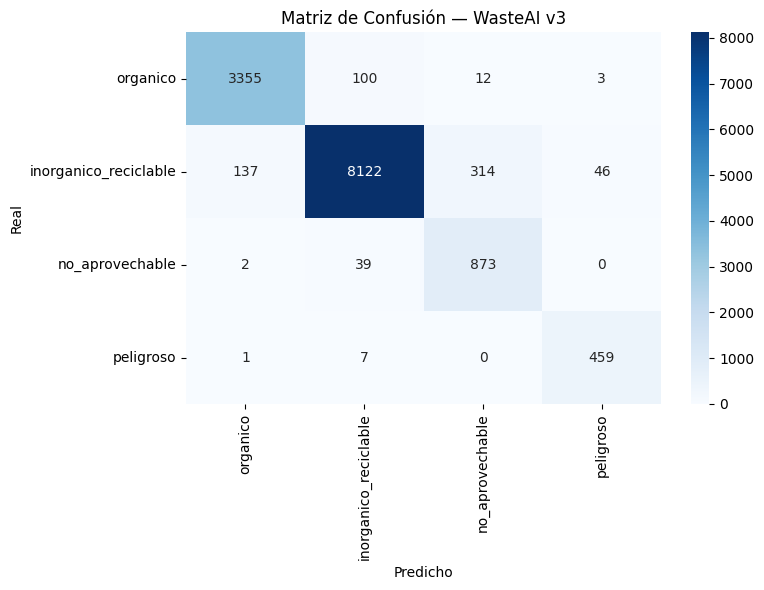

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

CLASES = ['organico', 'inorganico_reciclable', 'no_aprovechable', 'peligroso']

# Cargar mejor modelo
model = tf.keras.models.load_model('/content/wasteai_v3_best.keras')

# Dataset de validación
val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset_v3_final',
    validation_split=0.2, subset='validation',
    seed=42, image_size=(224,224), batch_size=16,
    class_names=CLASES,
).prefetch(tf.data.AUTOTUNE)

# Predicciones
y_true, y_pred = [], []
for imgs, labels in val_ds:
    preds = model.predict(imgs, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Reporte
print(classification_report(y_true, y_pred, target_names=CLASES))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASES, yticklabels=CLASES)
plt.title('Matriz de Confusión — WasteAI v3')
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.tight_layout(); plt.show()

In [ ]:
import tensorflow as tf
import numpy as np

# Cargar modelo
model = tf.keras.models.load_model('/content/wasteai_v3_best.keras')

# ── Conversión 1: Float32 (máxima precisión) ──────────────
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('/content/wasteai_v3.tflite', 'wb') as f:
    f.write(tflite_model)
print(f'✅ Float32: {len(tflite_model)/1024/1024:.2f} MB')

# ── Conversión 2: Int8 cuantizado (más ligero para móvil) ─
# Necesita dataset de calibración
val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset_v3_final',
    validation_split=0.2, subset='validation',
    seed=42, image_size=(224,224), batch_size=16,
    class_names=['organico','inorganico_reciclable','no_aprovechable','peligroso'],
).take(100)  # 100 batches para calibración

def representative_dataset():
    for imgs, _ in val_ds:
        for img in imgs:
            yield [tf.expand_dims(img, 0)]

converter2 = tf.lite.TFLiteConverter.from_keras_model(model)
converter2.optimizations = [tf.lite.Optimize.DEFAULT]
converter2.representative_dataset = representative_dataset
converter2.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter2.inference_input_type  = tf.uint8
converter2.inference_output_type = tf.uint8

tflite_quant = converter2.convert()
with open('/content/wasteai_v3_int8.tflite', 'wb') as f:
    f.write(tflite_quant)
print(f'✅ Int8 cuantizado: {len(tflite_quant)/1024/1024:.2f} MB')

Saved artifact at '/tmp/tmpuewu3psc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137750786949776: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  137750786957648: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  137750768857168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137750768856976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137750768855824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137750768858512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137750768859088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137750768857936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137750768857744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137750768858896: TensorSpec(shape=(), dtype=tf.resource, name=Non

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ Int8 cuantizado: 4.84 MB


In [ ]:
!pip install tf2onnx onnx -q

import tf2onnx
import tensorflow as tf
import numpy as np

model = tf.keras.models.load_model('/content/wasteai_v3_best.keras')

# Convertir a ONNX
input_signature = [tf.TensorSpec([1, 224, 224, 3], tf.float32, name='input')]
onnx_model, _ = tf2onnx.convert.from_keras(model, input_signature=input_signature, opset=13)

import onnx
onnx.save(onnx_model, '/content/wasteai_v3.onnx')

size_mb = len(onnx_model.SerializeToString()) / 1024 / 1024
print(f'✅ ONNX guardado: {size_mb:.2f} MB')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 67.5 MB/s eta 0:00:00
✅ ONNX guardado: 15.97 MB


In [ ]:
!pip install tf2onnx onnx onnxruntime -q

import tf2onnx
import tensorflow as tf
import onnx
import onnxruntime as ort
import numpy as np

# Cargar y convertir
model = tf.keras.models.load_model('/content/wasteai_v3_best.keras')
input_signature = [tf.TensorSpec([1, 224, 224, 3], tf.float32, name='input')]
onnx_model, _ = tf2onnx.convert.from_keras(model, input_signature=input_signature, opset=13)
onnx.save(onnx_model, '/content/wasteai_v3.onnx')
print(f'✅ ONNX guardado: {len(onnx_model.SerializeToString())/1024/1024:.2f} MB')

# Verificar
sess = ort.InferenceSession('/content/wasteai_v3.onnx')
print('Input name: ', sess.get_inputs()[0].name)
print('Input shape:', sess.get_inputs()[0].shape)
print('Output shape:', sess.get_outputs()[0].shape)

dummy = np.random.rand(1, 224, 224, 3).astype(np.float32)
out = sess.run(None, {sess.get_inputs()[0].name: dummy})
print('Test output:', out[0])
print('✅ Verificado correctamente')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 48.2 MB/s eta 0:00:00
✅ ONNX guardado: 15.97 MB
Input name:  input
Input shape: [1, 224, 224, 3]
Output shape: [1, 4]
Test output: [[0.26722065 0.2936189  0.25170276 0.18745776]]
✅ Verificado correctamente


In [ ]:
from google.colab import files
files.download('/content/wasteai_v3.onnx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('/content/wasteai_v3.tflite')
files.download('/content/wasteai_v3_int8.tflite')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## ✅ Fase 1 Completada

### Archivos generados en Google Drive → `MyDrive/ITGAM_WasteAI/`

| Archivo | Uso |
|---|---|
| `modelo_tfjs.zip` | **Subir a Vercel** — contiene `model.json`, shards y `metadata.json` |
| `mejor_modelo_pytorch.pth` | Re-entrenamiento futuro (Fase 3 — dataset propio) |
| `matriz_confusion.png` | Evaluación del modelo |
| `muestras_dataset.png` | Verificación del mapeo de clases |

---

### 🛣️ Siguiente paso según el roadmap: **Fase 2 — App Web en Vercel**

Con el modelo en Drive, los siguientes pasos son:

1. Extraer `modelo_tfjs.zip` y colocar los archivos en `/public/model/` del proyecto Vercel
2. Construir la interfaz web con acceso a cámara + carga de TF.js
3. Implementar clasificación en tiempo real
4. Integrar Gemini API para datos curiosos y consejos
5. Indicar el contenedor correcto según ITGAM-GA-007

> 💡 **Nota:** El `metadata.json` incluido en el ZIP tiene el mapeo de clases y el color `por_confirmar` para los contenedores que aún no tienes definidos del campus. Actualiza ese JSON cuando confirmes los colores reales.